# Load and Prepare Data

In [62]:
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_formats='retina'

import numpy as np
import pandas as pd

import warnings

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter('ignore', InterpolationWarning)

from sklearn.preprocessing import power_transform
from sklearn import set_config
set_config(transform_output="pandas")

# ADF test is used to determine the presence of unit root in the series, and hence helps in understand if the series is stationary or not. The null and alternate hypothesis of this test are:
# Null Hypothesis: The series has a unit root.
# Alternate Hypothesis: The series has no unit root.
# If the null hypothesis fails to be rejected, this test may provide evidence that the series is non-stationary.
def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(
        timeseries.dropna(),
        autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value

    if (dftest[1] < 0.05) & (dftest[4]['5%'] > dftest[0]):
        print(dfoutput)
        print("\u001b[32mConclusion: The data is stationary (Reject the null hypothesis)\u001b[0m")
    else:
        print(dfoutput)
        print("\x1b[31mConclusion: The data is not stationary (Fail to reject the null hypothesis)\x1b[0m")

# KPSS is another test for checking the stationarity of a time series. The null and alternate hypothesis for the KPSS test are opposite that of the ADF test.
# Null Hypothesis: The process is trend stationary.
# Alternate Hypothesis: The series has a unit root (series is not stationary).
def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(
        timeseries.dropna(), 
        regression="c", 
        nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], 
        index=[
            "Test Statistic", 
            "p-value", 
            "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value

    if (kpsstest[1] < 0.05) & (kpsstest[3]["5%"] > kpsstest[0]):
        print(kpss_output)
        print("\x1b[31mConclusion: The data is not stationary (Reject the null hypothesis)\x1b[0m")

    else:
        print(kpss_output)
        print("\u001b[32mConclusion: The data is stationary (Fail to reject the null hypothesis)\u001b[0m")

In [63]:
air_passengers = pd.read_csv("AirPassengers.csv")
air_passengers.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [64]:
air_passengers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [65]:
air_passengers['Month'] = pd.to_datetime(air_passengers['Month']) # convert to datetime
air_passengers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [66]:
air_passengers.set_index("Month", inplace=True) # set index based on time labels
air_passengers.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   #Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


In [67]:
air_passengers = air_passengers.resample("MS").sum() # resample by month start
air_passengers.index.freq = "MS"

In [68]:
air_passengers

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


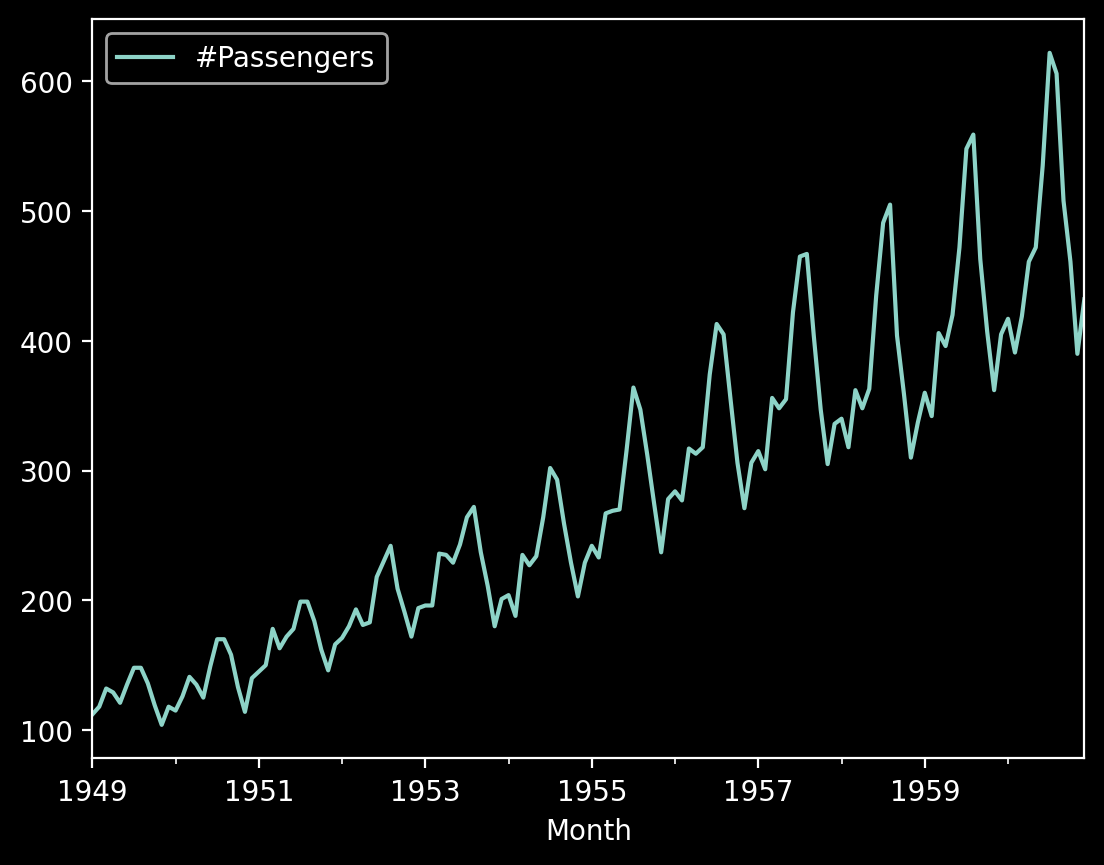

In [69]:
air_passengers.plot();

In [70]:
adf_test(air_passengers)

# Based upon the significance level of 0.05 and the p-value of ADF test, the null hypothesis can not be rejected. 
# Hence, the series is non-stationary.

Results of Dickey-Fuller Test:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64
Conclusion: The data is not stationary (Fail to reject the null hypothesis)


In [71]:
kpss_test(air_passengers)

# Based upon the significance level of 0.05 and the p-value of KPSS test, there is evidence for rejecting the null hypothesis in favor of the alternative.
# Hence, the series is stationary as per the KPSS test.

Results of KPSS Test:
Test Statistic           1.651312
p-value                  0.010000
Lags Used                8.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64
Conclusion: The data is stationary (Fail to reject the null hypothesis)


It is always better to apply both the tests, so that it can be ensured that the series is truly stationary.

Possible outcomes of applying these stationary tests are as follows:
1. Both tests conclude that the series is not stationary - The series is not stationary  
2. Both tests conclude that the series is stationary - The series is stationary  
3. KPSS indicates stationarity and ADF indicates non-stationarity - The series is **trend stationary**.   
    Trend needs to be removed to make series **strict stationary**.  
    The detrended series is checked for stationarity.
4. KPSS indicates non-stationarity and ADF indicates stationarity - The series is **difference stationary**.  
    Differencing is to be used to make series **strict stationary**.  
    The differenced series is checked for stationarity.  

Here, due to the difference in the results from ADF test and KPSS test, it can be inferred that the series is **trend stationary** and not **strict stationary**.  
The series can be detrended by differencing or by model fitting.

# Plot the time series data with rolling mean and rolling standard deviation and see if it is stationary.


In [72]:
# create rolling mean and stdev
air_passengers_copy = air_passengers.copy()
air_passengers_copy["rolling_mean12"] = air_passengers_copy["#Passengers"].rolling(window=12).mean()
air_passengers_copy["rolling_std12"] = air_passengers_copy["#Passengers"].rolling(window=12).std()

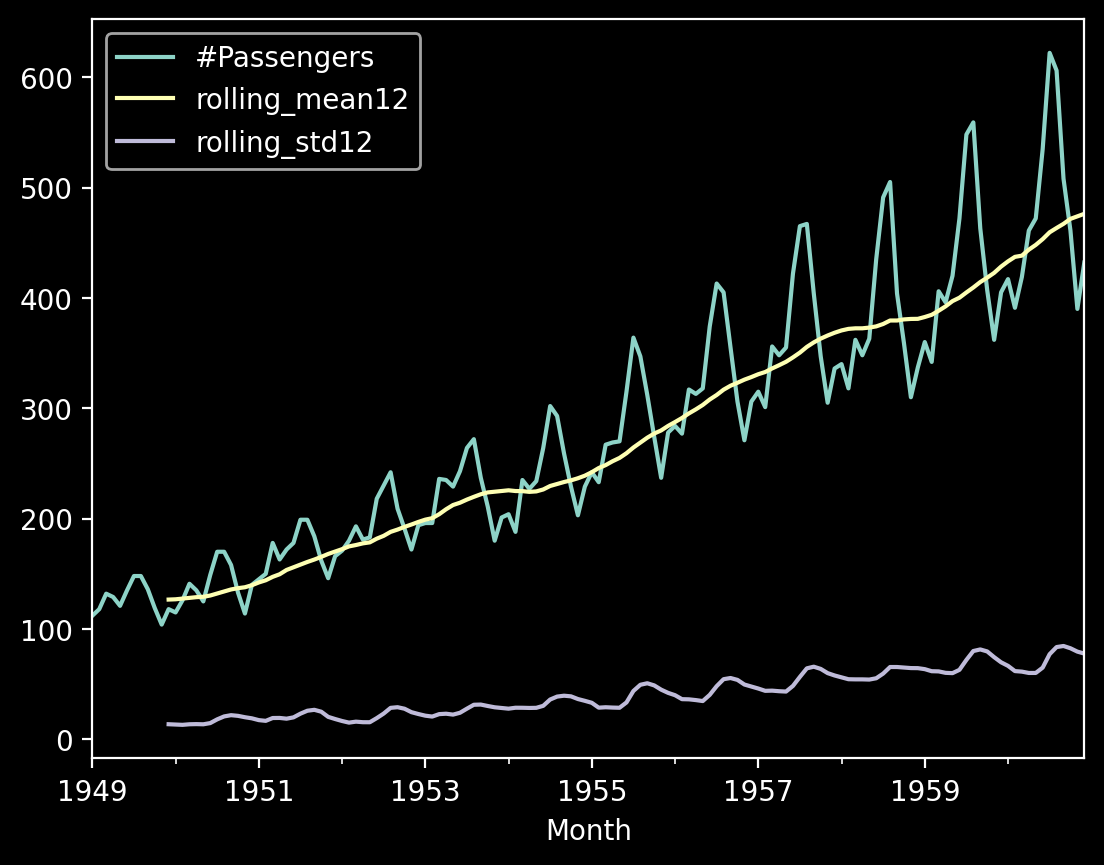

In [73]:
air_passengers_copy.plot();

# data does not appear stationary
# visually concurs with our tests above

# Try different levels of differences, and plot the time series data with rolling mean and standard deviation. See if it is stationary.

## Detrending by Differencing

A new series is constructed where the value at the current time step is calculated as the difference between the original observation and the observation at the previous time step.

In [74]:
air_passengers_differences = air_passengers.copy()

air_passengers_differences = pd.concat(
     [
     # air_passengers_differences, 
     air_passengers_differences.copy().diff().add_suffix("_diff1"),
     air_passengers_differences.copy().diff().diff().add_suffix("_diff2"),
     air_passengers_differences.copy().diff().diff().diff().add_suffix("_diff3")

     ], 
     axis=1)

air_passengers_differences

,#Passengers_diff1,#Passengers_diff2,#Passengers_diff3
Month,,,
1949-01-01,NaN,NaN,NaN
1949-02-01,6.0,NaN,NaN
1949-03-01,14.0,8.0,NaN
1949-04-01,-3.0,-17.0,-25.0
1949-05-01,-8.0,-5.0,12.0
...,...,...,...
1960-08-01,-16.0,-103.0,-127.0
1960-09-01,-98.0,-82.0,21.0
1960-10-01,-47.0,51.0,133.0


### create rolling means and stdevs


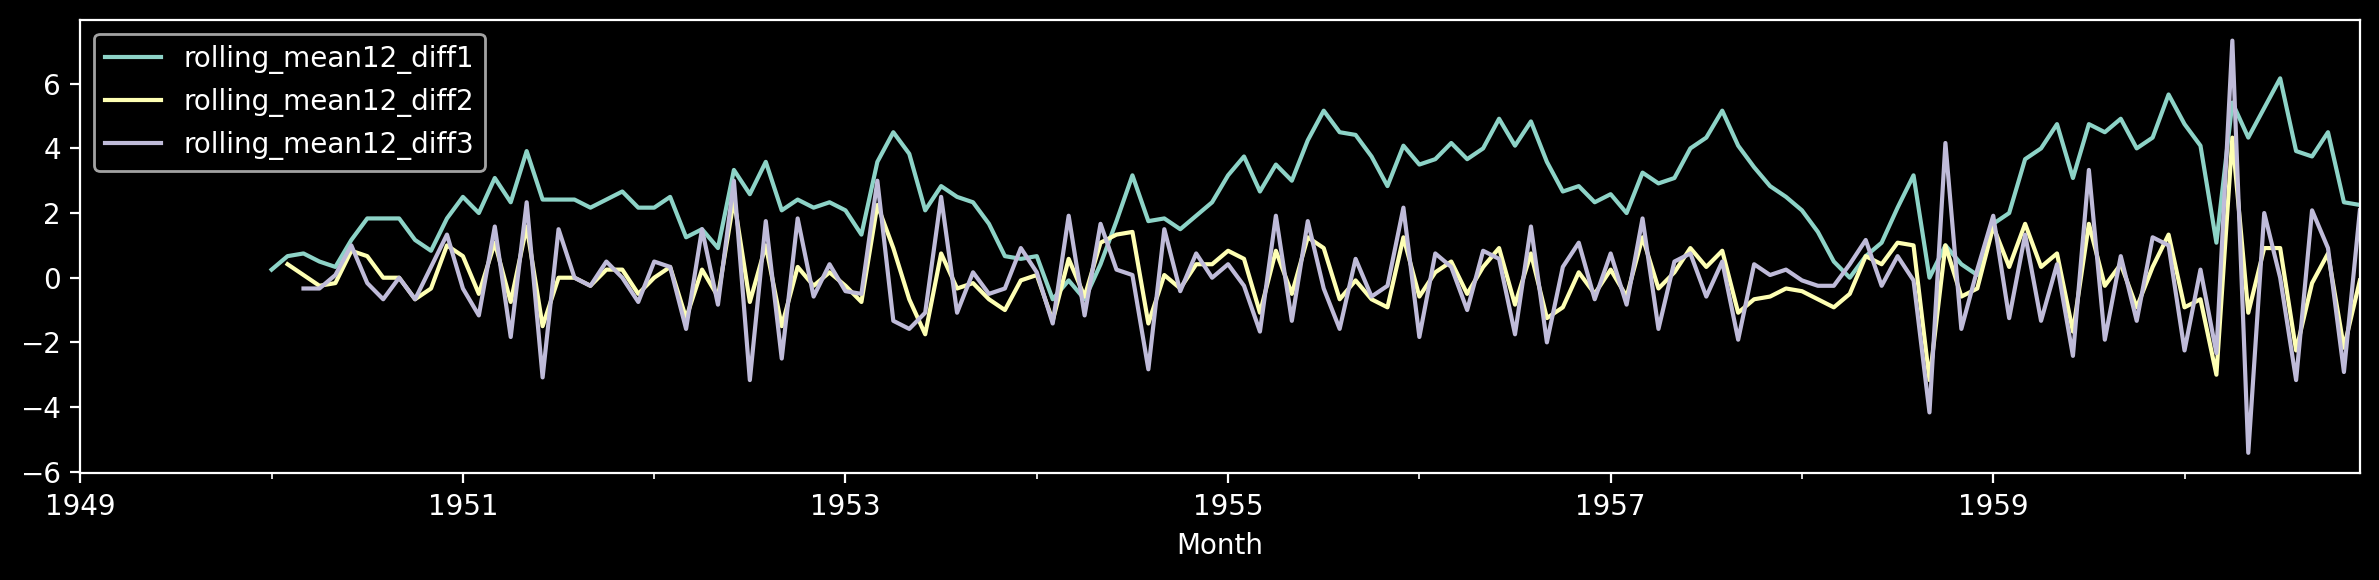

In [75]:
air_passengers_differences["rolling_mean12_diff1"] = (
    air_passengers_differences["#Passengers_diff1"].rolling(window=12).mean()
)
air_passengers_differences["rolling_mean12_diff2"] = (
    air_passengers_differences["#Passengers_diff2"].rolling(window=12).mean()
)
air_passengers_differences["rolling_mean12_diff3"] = (
    air_passengers_differences["#Passengers_diff3"].rolling(window=12).mean()
)


air_passengers_differences.plot(
    y=["rolling_mean12_diff1", "rolling_mean12_diff2", "rolling_mean12_diff3"],
    figsize=(12,3)
)
plt.tight_layout();

# 2 orders of differences visually appear to yield a constant mean

ADF test is now applied on these detrended values and stationarity is checked.

In [76]:
adf_test(air_passengers_differences["#Passengers_diff2"])

Results of Dickey-Fuller Test:
Test Statistic                -1.638423e+01
p-value                        2.732892e-29
#Lags Used                     1.100000e+01
Number of Observations Used    1.300000e+02
Critical Value (1%)           -3.481682e+00
Critical Value (5%)           -2.884042e+00
Critical Value (10%)          -2.578770e+00
dtype: float64
Conclusion: The data is stationary (Reject the null hypothesis)


Based upon the p-value of ADF test, there is evidence for rejecting the null hypothesis in favor of the alternative. Hence, the series is strict stationary now.   
KPSS test is now applied on these detrended values and stationarity is checked.

In [77]:
kpss_test(air_passengers_differences["#Passengers_diff2"])

Results of KPSS Test:
Test Statistic            0.134671
p-value                   0.100000
Lags Used                30.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64
Conclusion: The data is stationary (Fail to reject the null hypothesis)


Based upon the p-value of KPSS test, the null hypothesis can not be rejected. Hence, the series is stationary.

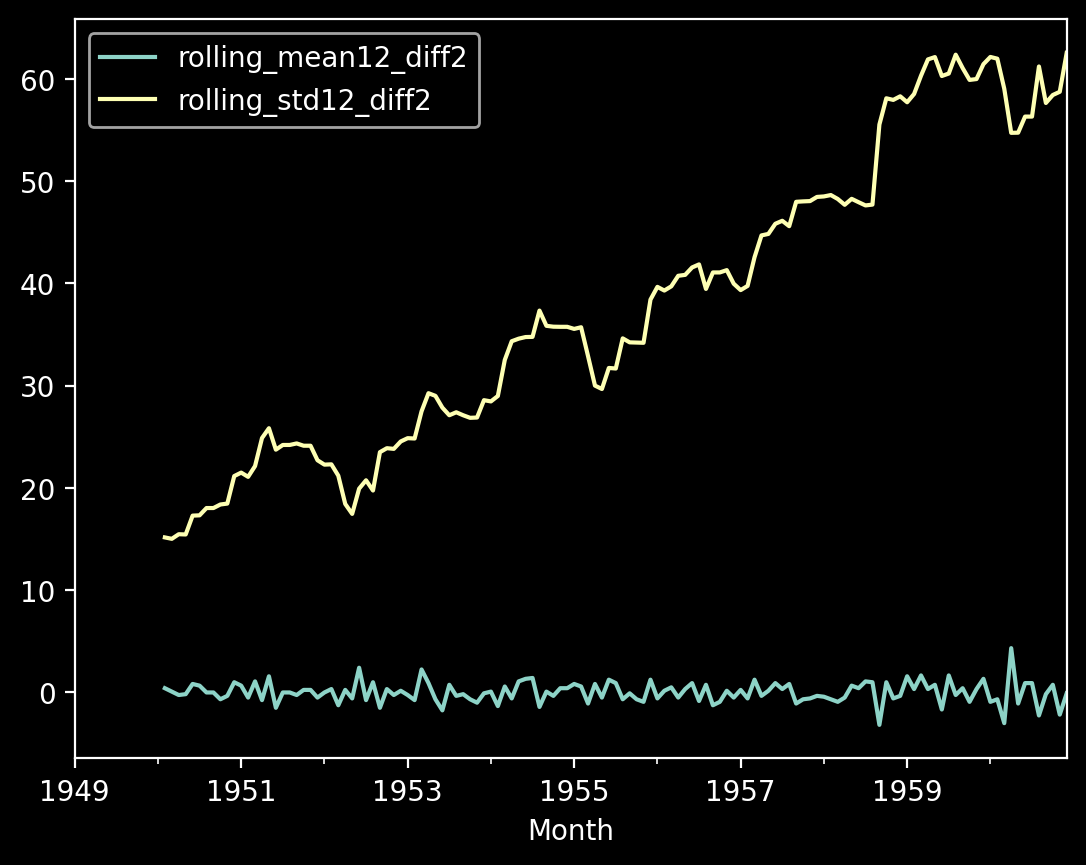

In [78]:
air_passengers_differences["rolling_std12_diff2"] = air_passengers_differences["#Passengers_diff2"].rolling(window=12).std()

air_passengers_differences.plot(y=["rolling_mean12_diff2", "rolling_std12_diff2"]);
# although the series passes ADF and KPSS, there is still increasing variance so we look to transform


# Try to transform the data, and make different levels of differences. See if it is stationary.


## Detrending by Transforming

A new series is constructed where the value at the current time step is calculated as the difference between the transformed original observation and the transformed observation at the previous time step.

In [79]:
air_passengers_transforms = air_passengers.copy()

air_passengers_transforms = pd.concat(
     [
     # air_passengers_transforms, 
     np.log(air_passengers_transforms).diff().diff().add_suffix("_ln_diff_diff"),
     np.log10(air_passengers_transforms).diff().diff().add_suffix("_log10_diff_diff"),
     power_transform(air_passengers_transforms, method="yeo-johnson").diff().diff().add_suffix("_yj_diff_diff"),
     power_transform(air_passengers_transforms, method="box-cox").diff().diff().add_suffix("_bc_diff_diff"),
     ], 
     axis=1)

air_passengers_transforms

,#Passengers_ln_diff_diff,#Passengers_log10_diff_diff,#Passengers_yj_diff_diff,#Passengers_bc_diff_diff
Month,,,,
1949-01-01,NaN,NaN,NaN,NaN
1949-02-01,NaN,NaN,NaN,NaN
1949-03-01,0.059932,0.026028,0.123957,0.124079
1949-04-01,-0.135107,-0.058676,-0.276766,-0.277113
1949-05-01,-0.041032,-0.017820,-0.083659,-0.083774
...,...,...,...,...
1960-08-01,-0.176733,-0.076754,-0.454717,-0.454798
1960-09-01,-0.150338,-0.065291,-0.383091,-0.383128
1960-10-01,0.079315,0.034446,0.207572,0.207634


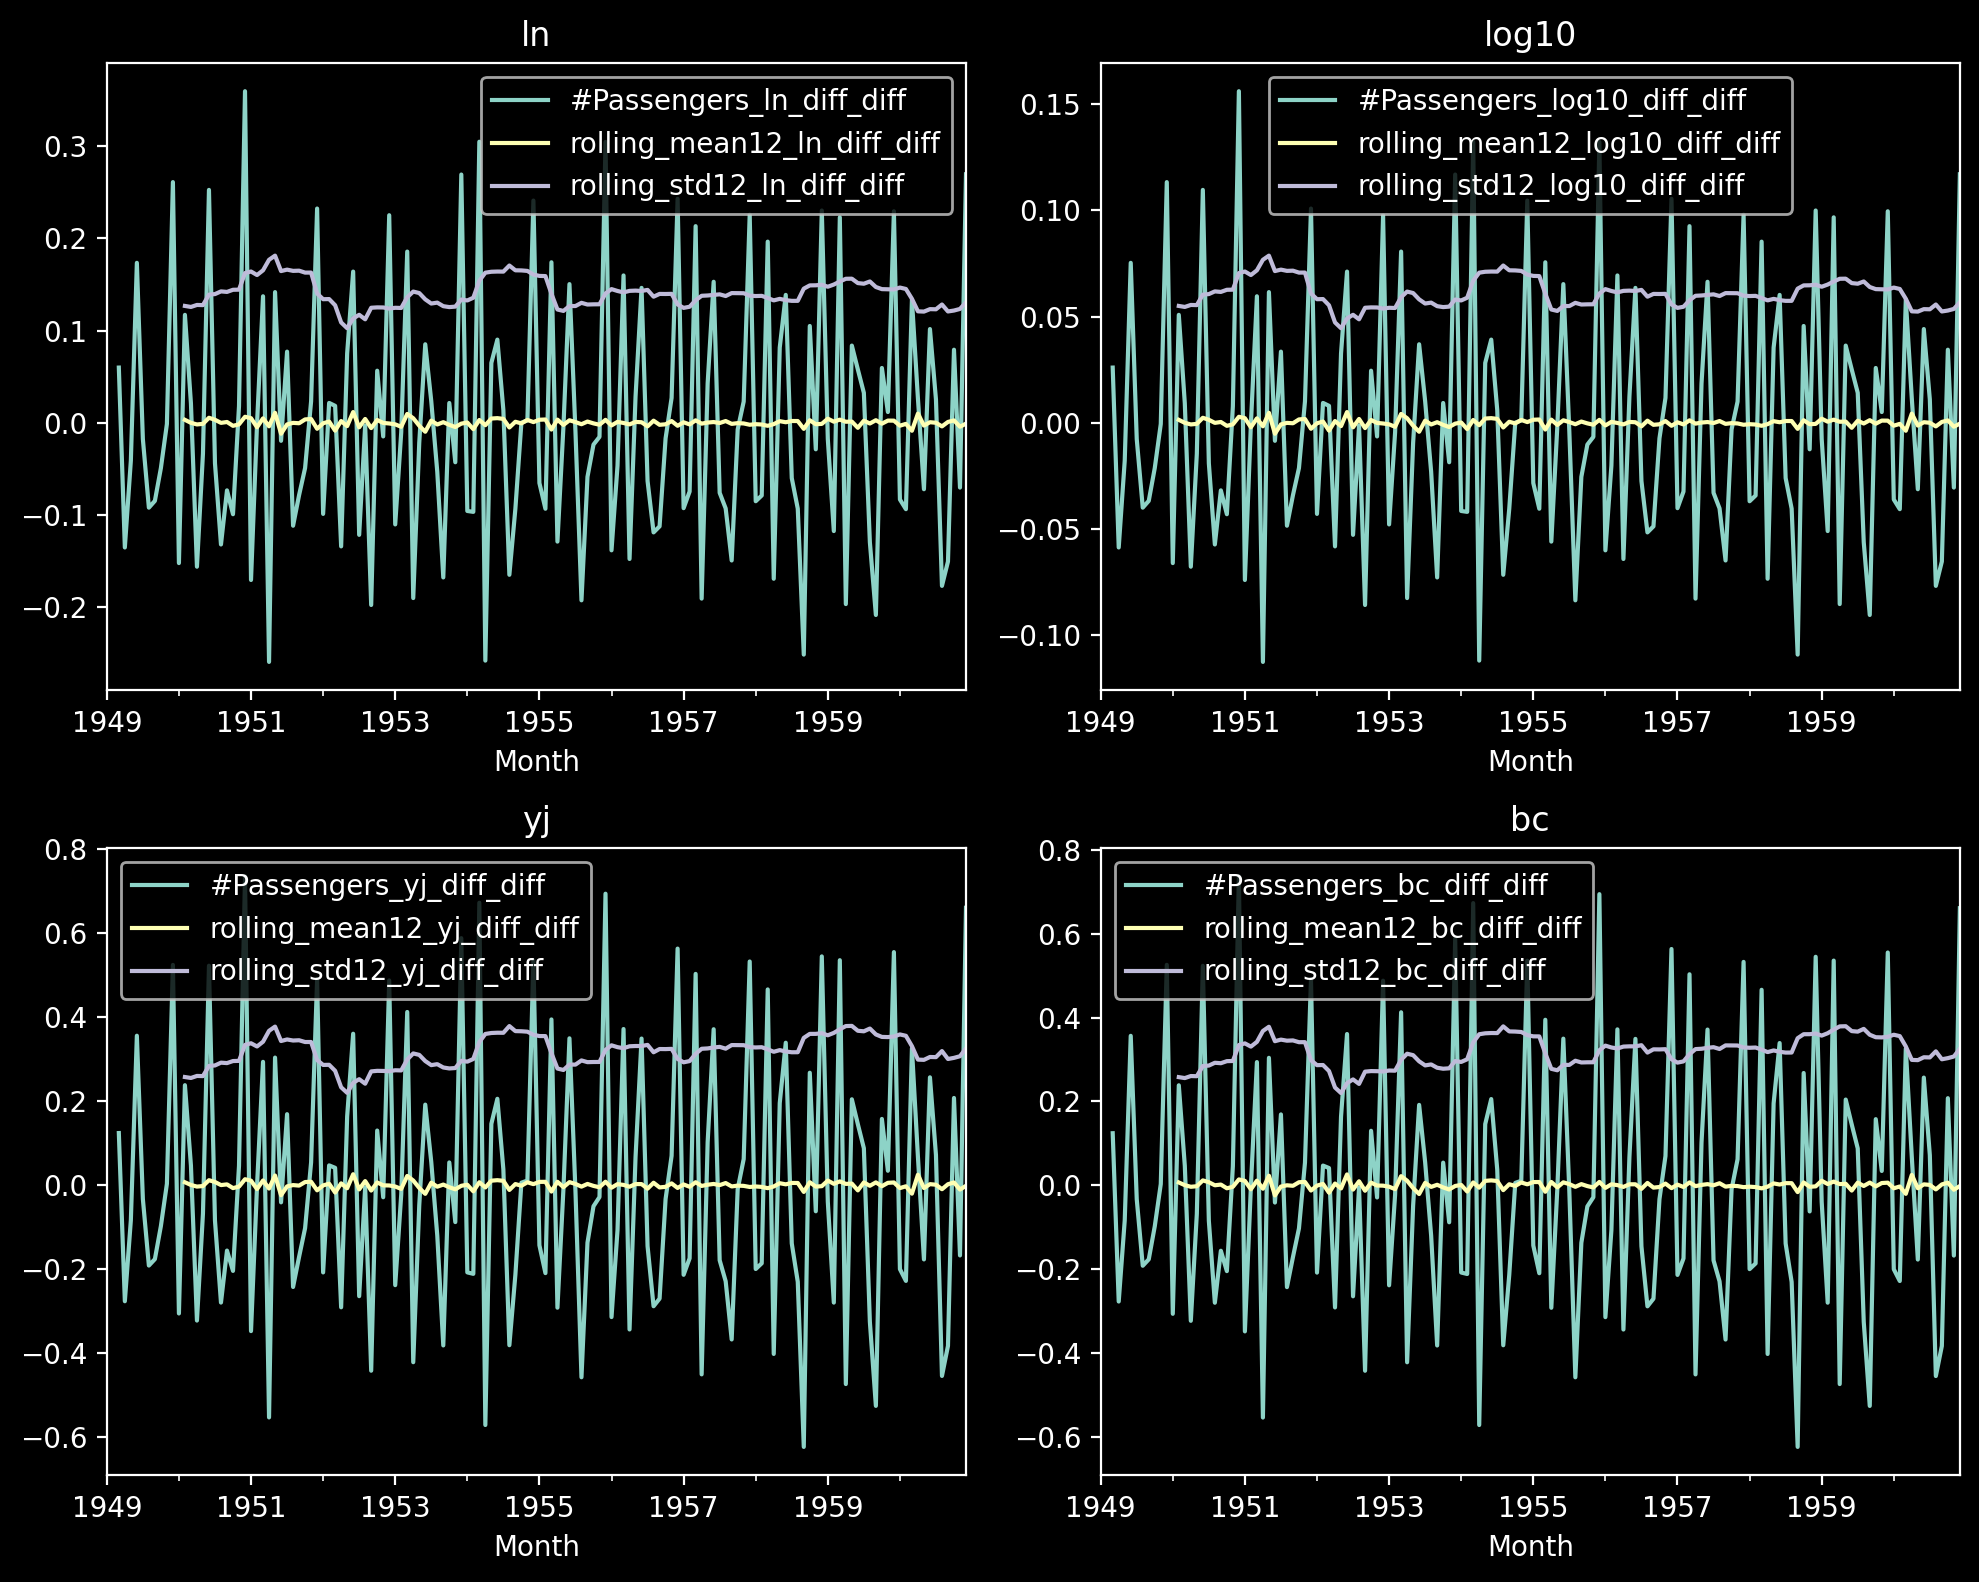

In [80]:
# look at a 12-month window to check mean and standard deviation

air_passengers_transforms["rolling_mean12_ln_diff_diff"] = air_passengers_transforms["#Passengers_ln_diff_diff"].rolling(window=12).mean()
air_passengers_transforms["rolling_std12_ln_diff_diff"] = air_passengers_transforms["#Passengers_ln_diff_diff"].rolling(window=12).std()

air_passengers_transforms["rolling_mean12_log10_diff_diff"] = air_passengers_transforms["#Passengers_log10_diff_diff"].rolling(window=12).mean()
air_passengers_transforms["rolling_std12_log10_diff_diff"] = air_passengers_transforms["#Passengers_log10_diff_diff"].rolling(window=12).std()


air_passengers_transforms["rolling_mean12_yj_diff_diff"] = air_passengers_transforms["#Passengers_yj_diff_diff"].rolling(window=12).mean()
air_passengers_transforms["rolling_std12_yj_diff_diff"] = air_passengers_transforms["#Passengers_yj_diff_diff"].rolling(window=12).std()

air_passengers_transforms["rolling_mean12_bc_diff_diff"] = air_passengers_transforms["#Passengers_bc_diff_diff"].rolling(window=12).mean()
air_passengers_transforms["rolling_std12_bc_diff_diff"] = air_passengers_transforms["#Passengers_bc_diff_diff"].rolling(window=12).std()


# Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(10, 8))  # Adjust figsize as needed

# Plot each column in a separate subplot
air_passengers_transforms.plot(y=["#Passengers_ln_diff_diff", "rolling_mean12_ln_diff_diff", "rolling_std12_ln_diff_diff"], ax=axes[0, 0], title='ln', legend=True)
air_passengers_transforms.plot(y=["#Passengers_log10_diff_diff", "rolling_mean12_log10_diff_diff", "rolling_std12_log10_diff_diff"], ax=axes[0, 1], title='log10', legend=True)
air_passengers_transforms.plot(y=["#Passengers_yj_diff_diff", "rolling_mean12_yj_diff_diff", "rolling_std12_yj_diff_diff"], ax=axes[1, 0], title='yj', legend=True)
air_passengers_transforms.plot(y=["#Passengers_bc_diff_diff", "rolling_mean12_bc_diff_diff", "rolling_std12_bc_diff_diff"], ax=axes[1, 1], title='bc', legend=True)

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# Display the plot
plt.show();

# other than scales all the transforms seem to transform the same so we choose natural log

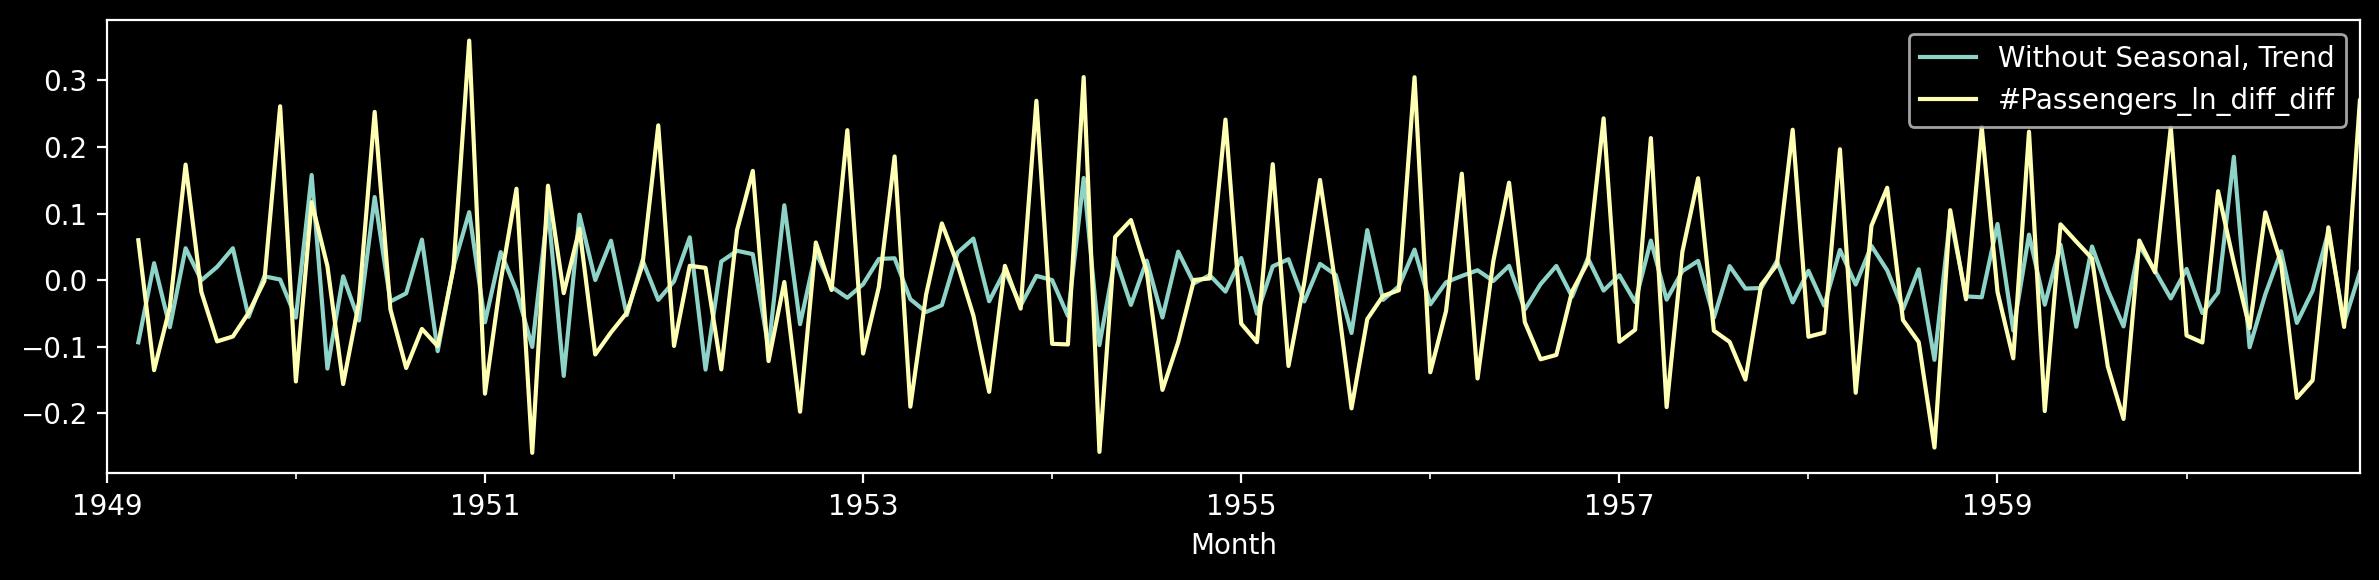

In [84]:
decomposition = seasonal_decompose(air_passengers_transforms["#Passengers_ln_diff_diff"].dropna(), extrapolate_trend="freq")
seasonals = decomposition.seasonal
trends = decomposition.trend

no_seasonal_trend = air_passengers_transforms["#Passengers_ln_diff_diff"] - seasonals - trends
no_seasonal_trend.plot(label="Without Seasonal, Trend", figsize=(15,3))

air_passengers_transforms["#Passengers_ln_diff_diff"].plot(figsize=(12,3))

plt.legend()
plt.tight_layout();


# Get the p-value from Augmented Dickey-Fuller test to make the data stationary.

ADF test is now applied on these detrended values and stationarity is checked.

In [85]:
adf_test(no_seasonal_trend)

Results of Dickey-Fuller Test:
Test Statistic                -8.701235e+00
p-value                        3.804330e-14
#Lags Used                     1.300000e+01
Number of Observations Used    1.280000e+02
Critical Value (1%)           -3.482501e+00
Critical Value (5%)           -2.884398e+00
Critical Value (10%)          -2.578960e+00
dtype: float64
Conclusion: The data is stationary (Reject the null hypothesis)


Based upon the p-value of ADF test, there is evidence for rejecting the null hypothesis in favor of the alternative. Hence, the series is strict stationary now.   
KPSS test is now applied on these detrended values and stationarity is checked.

In [86]:
kpss_test(no_seasonal_trend)

Results of KPSS Test:
Test Statistic            0.098399
p-value                   0.100000
Lags Used                14.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64
Conclusion: The data is stationary (Fail to reject the null hypothesis)


Based upon the p-value of KPSS test, the null hypothesis can not be rejected. Hence, the series is stationary.